In [39]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import glob, os
from difflib import get_close_matches
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist
from difflib import get_close_matches
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from itertools import combinations
import re
from sklearn.model_selection import cross_val_predict
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold
from scipy.spatial.distance import pdist, squareform
import json, warnings
from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Combining Sample and Control Files (qc, blank, env blank) for later removing contamination

In [2]:

# listing  the compounds samples data extracted by Nist library of unknown compound software
sample_files = [
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_9.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_14.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_21.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_28.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_44.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_53.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_55.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_83.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_92.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_1\sample_7.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_6.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_10.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_38.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_42.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_48.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_56.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_76.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_79.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_2\sample_86.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_5.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_16.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_39.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_50.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_60.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_68.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_81.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_87.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_3\sample_66.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_4.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_8.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_37.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_43.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_51.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_57.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_61.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_18.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_75.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_4\sample_94.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_1.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_35.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_30.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_71.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_73.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_88.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_93.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_12.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_5\sample_36.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_15.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_25.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_40.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_41.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_45.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_59.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_74.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_77.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_6\sample_49.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_2.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_24.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_31.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_32.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_34.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_90.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_58.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_64.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_70.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_7\sample_78.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_22.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_26.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_47.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_52.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_65.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_67.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_54.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_80.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_82.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_8\sample_85.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_3.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_13.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_17.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_20.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_23.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_27.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_29.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_62.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_9\sample_72.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_11.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_19.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_33.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_46.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_63.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_69.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_84.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_89.csv",
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\day_10\sample_91.csv",

]
# Replace these with  actual QC, env, blank file paths beacuse we want to remove the contamination and get the actual peaks for samples
qc_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\QC_*.csv")
env_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\env_*.csv")
blank_files= glob.glob(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds\blank_*.csv")
all_files = (
    [(f,"sample") for f in sample_files] +
    [(f, "qc") for f in qc_files] +
    [(f, "env") for f in env_files] +
    [(f, "blank") for f in blank_files]
)
rows = []
for fp, ftype in all_files:
    df = pd.read_csv(fp)
    df["FileType"] = ftype
    df["FileName"] = fp.split("\\")[-1]
    rows.append(df)
compound_df = pd.concat(rows, ignore_index=True)
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv"

# Save to CSV to use it later
compound_df .to_csv(output_path, index=False)
print(f"compound dataset saved to: {output_path}")
compound_df.head()

compound dataset saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_analysis\combined.csv


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


# Filtering True Sample Compounds

In [3]:
# Exclude compounds found in blanks/QCs/env
exclude = compound_df.loc[
    compound_df['FileType'].isin(['blank', 'env', 'qc']),
    'Compound Name'
].unique()

# Keep only actual sample compounds, removing excluded ones
real = compound_df.loc[
    (compound_df['FileType'] == 'sample') &
    (~compound_df['Compound Name'].isin(exclude))
].copy()

# Print filtered data shape and show head
print("Filtered sample compounds:", real.shape)
real.head()

Filtered sample compounds: (2394, 7)


,Component RT,Compound Name,Match Factor,Best Hit,Formula,FileType,FileName
0,2.185667,"2-Propanone, 1-methoxy-",91.035716,True,C4H8O2,sample,sample_7.csv
1,2.899483,"Butanal, 3-methyl-",95.554383,True,C5H10O,sample,sample_7.csv
2,3.317483,Pentanal,91.360114,True,C5H10O,sample,sample_7.csv
3,4.069867,"Disulfide, dimethyl",94.565354,True,C2H6S2,sample,sample_7.csv
4,5.282067,Hexanal,93.609765,True,C6H12O,sample,sample_7.csv


In [ ]:
# the cleaned_sample_data is the sample data after prepration 
cleaned_sample_data=pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\cleaned_features_with_meta.csv")

# Build sample_matching dictionary automatically
sample_matching = {}
for col in cleaned_sample_data.columns:
    match = re.search(r'S96_(\d+)_B1_D\d+_T1', col)
    if match:
        sample_num = match.group(1)
        filename = f'sample_{sample_num}.csv'
        sample_matching[filename] = col

# Manually add missing samples 46 and 47
sample_matching['sample_46.csv'] = 's179 S96_46_B1_D10_T2'
sample_matching['sample_47.csv'] = 's148 S96_47_B1_D8_T2'

print("Sample matching dictionary with added missing samples:")
print(sample_matching)

# Define function to find closest peak by RT with tolerance
def find_closest_peak(rt, peaks_rt, tol=0.1):
    diffs = np.abs(peaks_rt - rt)
    min_diff = diffs.min()
    if min_diff <= tol:
        return diffs.idxmin()  # index of closest peak
    else:
        return None

# Match compounds to intensities in cleaned_sample_data
matches = []
peaks_rt = cleaned_sample_data['tR_best']

for i, row in compound_df.iterrows():
    file_name = row['FileName']
    sample_col = sample_matching.get(file_name)
    if sample_col is None:
        # No matching sample column found for this compound
        continue
    
    compound_rt = row['Component RT']
    peak_idx = find_closest_peak(compound_rt, peaks_rt)
    
    if peak_idx is None:
        # No peak found within tolerance for this compound RT
        continue
    
    intensity = cleaned_sample_data.loc[peak_idx, sample_col]
    
    matches.append({
        'Compound Name': row['Compound Name'],
        'FileName': file_name,
        'Sample': sample_col,
        'Component RT': compound_rt,
        'Peak': cleaned_sample_data.loc[peak_idx, 'Peak'],
        'tR_best': cleaned_sample_data.loc[peak_idx, 'tR_best'],
        'm/z': cleaned_sample_data.loc[peak_idx, 'm/z'],
        'Intensity': intensity
    })

#  final matched DataFrame
compound_intesity_df = pd.DataFrame(matches)

print(f"Number of matched compound intensities: {compound_intesity_df .shape[0]}")
print(compound_intesity_df .head())
print(compound_intesity_df.shape)

Sample matching dictionary with added missing samples:
{'sample_10.csv': 's26 S96_10_B1_D2_T1', 'sample_11.csv': 's169 S96_11_B1_D10_T1', 'sample_12.csv': 's78 S96_12_B1_D5_T1', 'sample_13.csv': 's153 S96_13_B1_D9_T1', 'sample_14.csv': 's2 S96_14_B1_D1_T1', 'sample_15.csv': 's93 S96_15_B1_D6_T1', 'sample_16.csv': 's39 S96_16_B1_D3_T1', 'sample_17.csv': 's151 S96_17_B1_D9_T1', 'sample_18.csv': 's59 S96_18_B1_D4_T1', 'sample_19.csv': 's174 S96_19_B1_D10_T1', 'sample_1.csv': 's80 S96_1_B1_D5_T1', 'sample_20.csv': 's152 S96_20_B1_D9_T1', 'sample_21.csv': 's6 S96_21_B1_D1_T1', 'sample_22.csv': 's137 S96_22_B1_D8_T1', 'sample_23.csv': 's154 S96_23_B1_D9_T1', 'sample_24.csv': 's119 S96_24_B1_D7_T1', 'sample_25.csv': 's95 S96_25_B1_D6_T1', 'sample_26.csv': 's140 S96_26_B1_D8_T1', 'sample_27.csv': 's157 S96_27_B1_D9_T1', 'sample_28.csv': 's4 S96_28_B1_D1_T1', 'sample_29.csv': 's150 S96_29_B1_D9_T1', 'sample_2.csv': 's114 S96_2_B1_D7_T1', 'sample_30.csv': 's79 S96_30_B1_D5_T1', 'sample_31.csv': 

In [5]:
compound_intesity_df .to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\compound_intensity.csv", index=False)
len(compound_intesity_df['Sample'].unique())

94

# Checking the presence of known potato aroma compounds

In [ ]:

potato_aromas = [
    "Hexanal", "Nonanal", "Pentanal", "2-Methylbutanal", "3-Methylbutanal",
    "1-Octen-3-ol", "Benzaldehyde", "1-Phenylethanol", "Methional",
    "Dimethyl trisulfide", "Furfural", "2,3-Butanedione", "Ethyl butanoate",
    "2-Acetylpyrazine", "Dimethyl disulfide", "2-Propanone, 1-methoxy-",
    "Cyclotrisiloxane, hexamethyl-", "3-Octanone", "Hexanol", "Butanal, 3-methyl-",
    "Heptanal", "Octanal", "Decanal",
    "2-Heptanone", "2-Nonanone", "3-Heptanone",
    "Ethyl hexanoate", "Methyl butanoate", "Ethyl 2-methylbutanoate",
    "2-Ethyl-3,5-dimethylpyrazine", "2-Isobutyl-3-methoxypyrazine",
    "1-Heptanol", "1-Nonanol",
    "Methanethiol", "Dimethyl tetrasulfide", "Carbon disulfide",
    "Acetic acid", "Butanoic acid", "Hexanoic acid"
]

def normalize(name):
    return name.lower().replace(' ', '').replace('-', '').replace(',', '')

# Normalize aroma list into dictionary: normalized name -> original name
ref_norm = {normalize(x): x for x in potato_aromas}

# Normalize compound names in matched_df
compound_intesity_df['norm_name'] = compound_intesity_df['Compound Name'].apply(normalize)

# Exact matches
compound_intesity_df['is_aroma'] =compound_intesity_df['norm_name'].isin(ref_norm)

# Fuzzy matching for compounds not exactly matched
def fuzzy_match(n, refs, cutoff=0.8):
    matches = get_close_matches(n, refs, n=1, cutoff=cutoff)
    return matches[0] if matches else None

mask = ~compound_intesity_df['is_aroma']
fuzzy_hits = compound_intesity_df.loc[mask, 'norm_name'].map(lambda n: fuzzy_match(n, list(ref_norm.keys())))

# Mark fuzzy matched as aroma and update 'Compound Name' with official name
compound_intesity_df.loc[mask & fuzzy_hits.notna(), 'is_aroma'] = True
compound_intesity_df.loc[mask & fuzzy_hits.notna(), 'Compound Name'] = fuzzy_hits.map(ref_norm)

# Filter only aroma compounds
aroma_sample_df = compound_intesity_df[compound_intesity_df['is_aroma']].copy()

print(f"Number of aroma compound records: {aroma_sample_df.shape[0]}")
print(aroma_sample_df.head())

len(aroma_sample_df['Sample'].unique())


Number of aroma compound records: 570
                   Compound Name      FileName              Sample  \
0             Butanal, 3-methyl-  sample_7.csv  s18 S96_7_B1_D1_T1   
1                       Pentanal  sample_7.csv  s18 S96_7_B1_D1_T1   
3                        Hexanal  sample_7.csv  s18 S96_7_B1_D1_T1   
4  Cyclotrisiloxane, hexamethyl-  sample_7.csv  s18 S96_7_B1_D1_T1   
5                   Benzaldehyde  sample_7.csv  s18 S96_7_B1_D1_T1   

   Component RT  Peak  tR_best  m/z  Intensity                   norm_name  \
0      2.899483    27    2.890   44  15.879306              butanal3methyl   
1      3.317483    41    3.375   81  19.455887                    pentanal   
3      5.282067    73    5.199  149  15.227984                     hexanal   
4      5.883333    80    5.903  207  17.026906  cyclotrisiloxanehexamethyl   
5      9.314117   145    9.347  267  17.161132                benzaldehyde   

   is_aroma  
0      True  
1      True  
3      True  
4      True  
5 

94

In [7]:
# Unique varieties before aroma assignment
varieties_before = set(compound_intesity_df['Sample'].unique())
print(f"Number of varieties before aroma assignment: {len(varieties_before)}")

# Unique varieties after aroma assignment (assuming aroma-assigned dataframe is aroma_per_variety or similar)
varieties_after = set(aroma_sample_df['Sample'].unique())
print(f"Number of varieties after aroma assignment: {len(varieties_after)}")

# Varieties missing aroma assignment
missing_varieties = varieties_before - varieties_after
print(f"Varieties missing aroma info: {missing_varieties}")


Number of varieties before aroma assignment: 94
Number of varieties after aroma assignment: 94
Varieties missing aroma info: set()


In [38]:
# missing_samples = ['s59 S96_18_B1_D4_T1', 's3 S96_9_B1_D1_T1', 's120 S96_90_B1_D7_T1', 's133 S96_54_B1_D8_T1']

# missing_data = compound_intesity_df[compound_intesity_df['Sample'].isin(missing_samples)]
# print(missing_data[['Sample', 'Compound Name', 'is_aroma']].head(20))

# # How many aroma compounds (is_aroma=True) are in these samples?
# print(missing_data.groupby('Sample')['is_aroma'].sum())


# Map variety on samples

In [9]:

# Load master table
master = pd.read_csv(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"
)

# Extract SampleNumber from your aroma_samples 'FileName' (assumes sample_##.csv format)
aroma_sample_df['SampleNumber'] = aroma_sample_df['FileName'].str.extract(r'(\d+)').astype(int)

# Filter master table to exclude blanks/QC etc.
valid_master = master[
    ~master['Sample'].isin(['Blank', 'QCB', 'QC1', 'QC2', 'QC3', 'QC4', 'EnvBlank'])
].copy()

# Extract SampleNumber from master 'Filename' column, e.g. "_12_B" => 12
valid_master['SampleNumber'] = valid_master['Filename'].str.extract(r'_([0-9]+)_B').astype(int)

# Extract Variety from master 'Sample' column
valid_master['Variety'] = valid_master['Sample'].str.split(';').str[-1].str.strip()

# Prepare mapping table: SampleNumber -> Variety (remove duplicates)
sample_to_variety = valid_master[['SampleNumber', 'Variety']].drop_duplicates()

# Merge variety info into aroma_samples by SampleNumber
aroma_per_variety = pd.merge(aroma_sample_df, sample_to_variety, on='SampleNumber', how='left')

# Drop the FileName column (if you don't need it)
aroma_per_variety = aroma_per_variety.drop(columns=['FileName'])

# Now print without the FileName column
print(aroma_per_variety)



                     Compound Name                 Sample  Component RT  Peak  \
0               Butanal, 3-methyl-     s18 S96_7_B1_D1_T1      2.899483    27   
1                         Pentanal     s18 S96_7_B1_D1_T1      3.317483    41   
2                          Hexanal     s18 S96_7_B1_D1_T1      5.282067    73   
3    Cyclotrisiloxane, hexamethyl-     s18 S96_7_B1_D1_T1      5.883333    80   
4                     Benzaldehyde     s18 S96_7_B1_D1_T1      9.314117   145   
..                             ...                    ...           ...   ...   
565  Cyclotrisiloxane, hexamethyl-  s171 S96_89_B1_D10_T1      5.886600    80   
566                   Benzaldehyde  s171 S96_89_B1_D10_T1      9.333467   145   
567  Cyclotrisiloxane, hexamethyl-  s173 S96_91_B1_D10_T1      5.886867    80   
568                   Benzaldehyde  s173 S96_91_B1_D10_T1      9.334584   145   
569                        Decanal  s173 S96_91_B1_D10_T1     13.722683   274   

     tR_best  m/z  Intensit

# Full dataframe including the varairty, aroma compounds and their description.

In [10]:
aroma_descriptions = {
    "Butanal, 3-methyl-": "Fruity, malty, chocolate",
    "Pentanal": "Green, fatty, pungent",
    "Hexanal": "Green, grassy",
    "Cyclotrisiloxane, hexamethyl-": "Chemical, silicone-like",
    "Benzaldehyde": "Almond, cherry, fruity",
    "Dimethyl trisulfide": "Garlic, onion, sulfurous",
    "Furfural": "Sweet, almond, caramel",
    "Methional": "Cooked potato, sulfurous",
    "Octanal": "Citrus, fruity",
    "Decanal": "Citrus, floral",
    "Hexanoic acid": "Fatty, cheesy, sweaty",
    "2,3-Butanedione": "Butter, creamy, sweet",
    "2-Acetylpyrazine": "Nutty, roasted",
    "Ethyl butanoate": "Fruity, pineapple, sweet",
    "Ethyl hexanoate": "Fruity, apple, pineapple",
    "Methyl butanoate": "Fruity, apple, sweet",
    "Ethyl 2-methylbutanoate": "Fruity, apple, sweet",
    "2-Ethyl-3,5-dimethylpyrazine": "Nutty, roasted, earthy",
    "2-Isobutyl-3-methoxypyrazine": "Green, bell pepper",
    "1-Heptanol": "Floral, herbal",
    "1-Nonanol": "Floral, waxy",
    "Methanethiol": "Sulfurous, cabbage",
    "Dimethyl tetrasulfide": "Garlic, sulfurous",
    "Carbon disulfide": "Sulfurous",
    "Acetic acid": "Vinegar, sour",
    "Butanoic acid": "Sweaty, cheesy",
    "2-Propanone, 1-methoxy-": "Solvent, chemical",
    "Cyclotrisiloxane, hexamethyl-": "Chemical, silicone-like",
    "3-Octanone": "Mushroom, earthy",
    "1-Phenylethanol": "Floral, rose",
    "2-Methylbutanal": "Malty, chocolate",
    "3-Methylbutanal": "Malty, chocolate",
    "1-Octen-3-ol": "Mushroom, earthy",
    "Dimethyl disulfide": "Garlic, onion",
    "Ethyl 2-methylbutanoate": "Fruity, apple",
}


aroma_per_variety['Aroma Description'] = aroma_per_variety['Compound Name'].map(aroma_descriptions)
print(aroma_per_variety.head(20))


                    Compound Name              Sample  Component RT  Peak  \
0              Butanal, 3-methyl-  s18 S96_7_B1_D1_T1      2.899483    27   
1                        Pentanal  s18 S96_7_B1_D1_T1      3.317483    41   
2                         Hexanal  s18 S96_7_B1_D1_T1      5.282067    73   
3   Cyclotrisiloxane, hexamethyl-  s18 S96_7_B1_D1_T1      5.883333    80   
4                    Benzaldehyde  s18 S96_7_B1_D1_T1      9.314117   145   
5             Dimethyl trisulfide  s18 S96_7_B1_D1_T1      9.519900   149   
6                         Octanal  s18 S96_7_B1_D1_T1     10.191900   172   
7                         Decanal  s18 S96_7_B1_D1_T1     13.703067   274   
8              Butanal, 3-methyl-   s3 S96_9_B1_D1_T1      2.899650    27   
9                         Hexanal   s3 S96_9_B1_D1_T1      5.282233    73   
10  Cyclotrisiloxane, hexamethyl-   s3 S96_9_B1_D1_T1      5.886717    80   
11                   Benzaldehyde   s3 S96_9_B1_D1_T1      9.314283   145   

# Aroma intensities per variety

In [11]:
aroma_pivot = aroma_per_variety.pivot_table(index='Variety', columns='Compound Name', values='Intensity', aggfunc='mean').fillna(0)

print(aroma_pivot.head())

Compound Name  1-Nonanol  2,3-Butanedione  Benzaldehyde  Butanal, 3-methyl-  \
Variety                                                                       
ADORA                0.0              0.0     17.984870           15.836435   
AGRIA                0.0              0.0     14.859493           14.154847   
ALOUETTE             0.0              0.0     15.205705           15.262178   
ALTHEA               0.0              0.0     19.535081           14.984406   
ALTURAS              0.0              0.0     20.293776           14.482897   

Compound Name  Cyclotrisiloxane, hexamethyl-    Decanal  Dimethyl trisulfide  \
Variety                                                                        
ADORA                              17.417208  18.203338              0.00000   
AGRIA                              15.947810  14.499810             17.21077   
ALOUETTE                           14.678352  17.462371              0.00000   
ALTHEA                             17.704453  

In [12]:

# Reset the index to make 'Variety' a normal column again
aroma_pivot_reset = aroma_pivot.reset_index()

# Rename columns with descriptions while keeping 'Variety' column unchanged
aroma_pivot_renamed = aroma_pivot_reset.copy()
aroma_pivot_renamed.columns = ['Variety'] + [
    f"{compound} ({aroma_descriptions.get(compound, 'No description')})"
    for compound in aroma_pivot_reset.columns[1:]
]

print(aroma_pivot_renamed.head())


    Variety  1-Nonanol (Floral, waxy)  \
0     ADORA                       0.0   
1     AGRIA                       0.0   
2  ALOUETTE                       0.0   
3    ALTHEA                       0.0   
4   ALTURAS                       0.0   

   2,3-Butanedione (Butter, creamy, sweet)  \
0                                      0.0   
1                                      0.0   
2                                      0.0   
3                                      0.0   
4                                      0.0   

   Benzaldehyde (Almond, cherry, fruity)  \
0                              17.984870   
1                              14.859493   
2                              15.205705   
3                              19.535081   
4                              20.293776   

   Butanal, 3-methyl- (Fruity, malty, chocolate)  \
0                                      15.836435   
1                                      14.154847   
2                                      15.262178   
3  

 PCA on aroma intensities

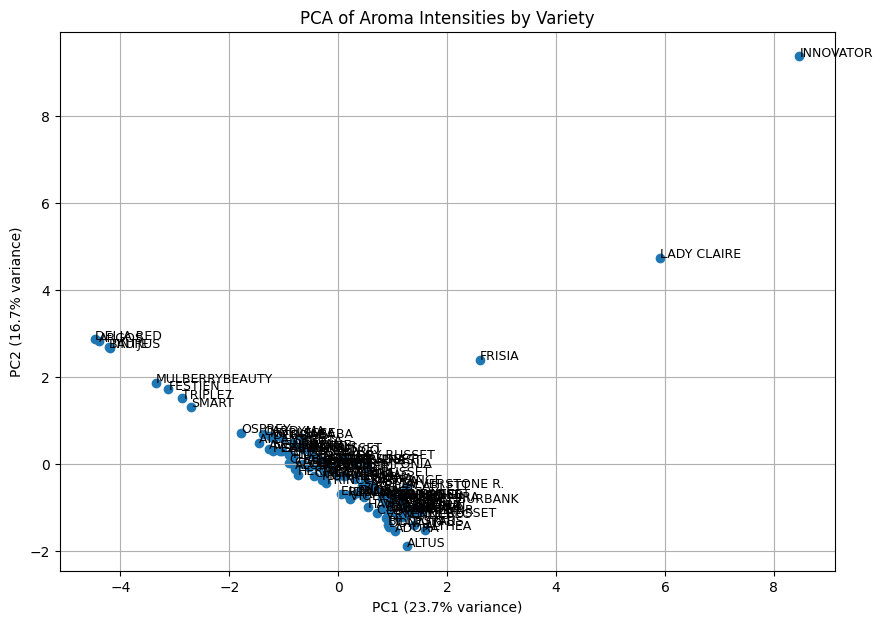

In [ ]:

# If 'Variety' is a column, set it as index:
if 'Variety' in aroma_pivot_renamed.columns:
    aroma_pivot_renamed.set_index('Variety', inplace=True)

# Now extract numeric data (no strings)
X_numeric = aroma_pivot_renamed.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))
plt.scatter(X_pca[:, 0], X_pca[:, 1])

# Use the index (varieties) for labels
for i, variety in enumerate(aroma_pivot_renamed.index):
    plt.text(X_pca[i, 0], X_pca[i, 1], variety, fontsize=9)

plt.xlabel('PC1 (%.1f%% variance)' % (pca.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (%.1f%% variance)' % (pca.explained_variance_ratio_[1]*100))
plt.title('PCA of Aroma Intensities by Variety')
plt.grid(True)
plt.show()

 INNOVATOR and LADY CLAIRE stand out as different from most others.

#  Statistics of aroma intensities per variety

In [14]:
# Calculate mean and std of each compound across varieties
desc_stats =aroma_pivot_renamed.describe().T  # transpose to have compounds as rows

# Show top compounds with highest mean intensity overall
top_compounds = desc_stats.sort_values(by='mean', ascending=False).head(10)
print("Top 10 aroma compounds by average intensity:")
print(top_compounds[['mean', 'std']])
aroma_pivot_renamed.head(5)

Top 10 aroma compounds by average intensity:
                                                         mean       std
Benzaldehyde (Almond, cherry, fruity)               16.398647  1.750228
Cyclotrisiloxane, hexamethyl- (Chemical, silico...  15.984822  1.582331
Decanal (Citrus, floral)                            14.820036  3.814669
Octanal (Citrus, fruity)                            13.156437  7.159785
Butanal, 3-methyl- (Fruity, malty, chocolate)       12.223914  6.220205
Dimethyl trisulfide (Garlic, onion, sulfurous)       8.927816  9.188503
Hexanal (Green, grassy)                              6.538783  7.387660
Pentanal (Green, fatty, pungent)                     3.201202  7.406310
Hexanoic acid (Fatty, cheesy, sweaty)                3.034014  7.384243
Furfural (Sweet, almond, caramel)                    0.443991  2.460374


,"1-Nonanol (Floral, waxy)","2,3-Butanedione (Butter, creamy, sweet)","Benzaldehyde (Almond, cherry, fruity)","Butanal, 3-methyl- (Fruity, malty, chocolate)","Cyclotrisiloxane, hexamethyl- (Chemical, silicone-like)","Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)","Hexanal (Green, grassy)","Hexanoic acid (Fatty, cheesy, sweaty)","Methional (Cooked potato, sulfurous)","Octanal (Citrus, fruity)","Pentanal (Green, fatty, pungent)"
Variety,,,,,,,,,,,,,
ADORA,0.0,0.0,17.984870,15.836435,17.417208,18.203338,0.00000,0.0,0.00000,22.334351,0.0,18.799602,0.000000
AGRIA,0.0,0.0,14.859493,14.154847,15.947810,14.499810,17.21077,0.0,0.00000,0.000000,0.0,15.924101,18.039118
ALOUETTE,0.0,0.0,15.205705,15.262178,14.678352,17.462371,0.00000,0.0,0.00000,0.000000,0.0,19.520823,0.000000
ALTHEA,0.0,0.0,19.535081,14.984406,17.704453,21.158234,0.00000,0.0,0.00000,18.548808,0.0,0.000000,20.209723
ALTURAS,0.0,0.0,20.293776,14.482897,14.257052,16.590508,0.00000,0.0,17.24572,0.000000,0.0,0.000000,0.000000


# Cluster Analysis

Number of unique varieties: 94
Some varieties: ['ADORA', 'AGRIA', 'ALOUETTE', 'ALTHEA', 'ALTURAS', 'ALTUS', 'ALVERSTONE R.', 'ANIVIA', 'ANTI', 'ARDECHE']


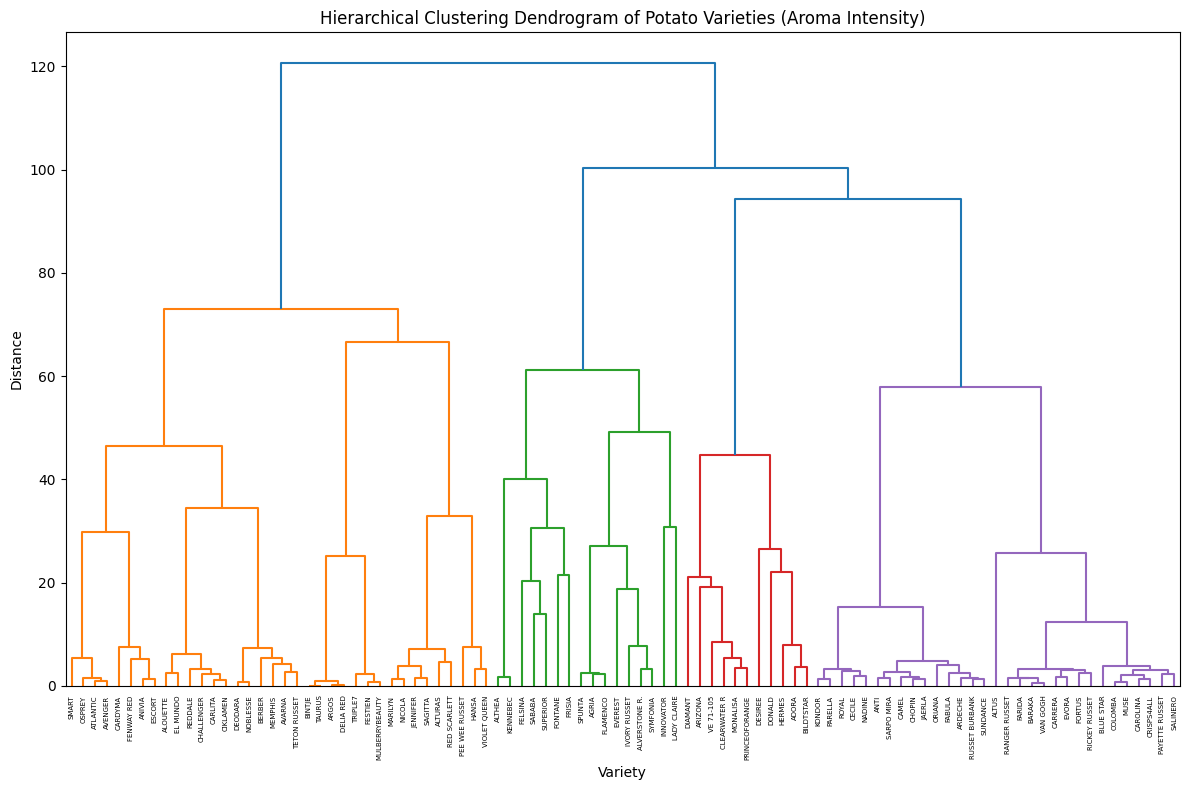

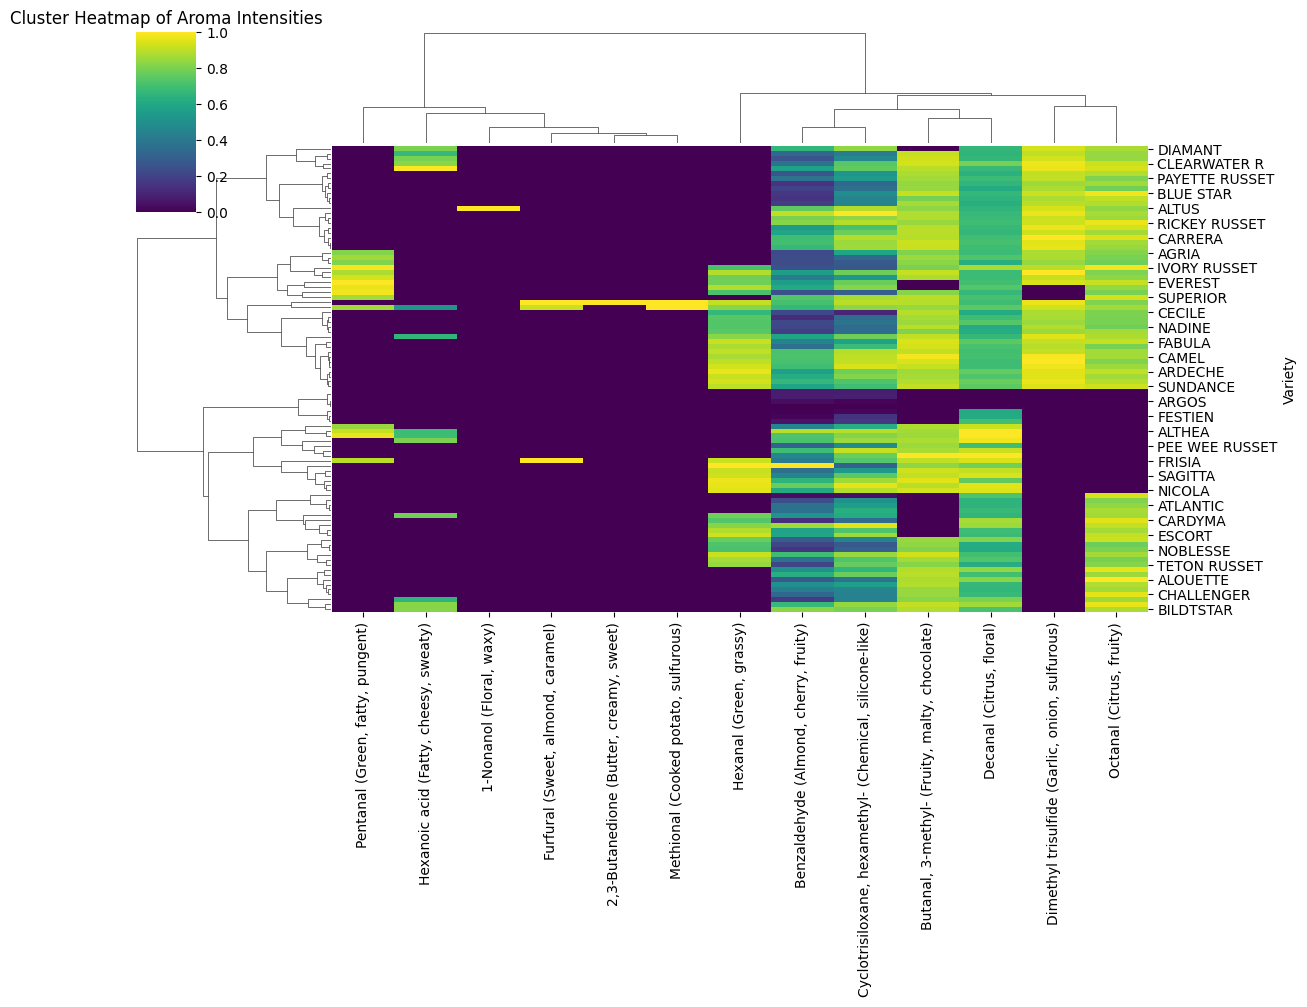

In [ ]:
# Number of unique varieties (index labels)
num_varieties = aroma_pivot_renamed.index.nunique()
print(f"Number of unique varieties: {num_varieties}")

#see the first few variety names
print("Some varieties:", aroma_pivot_renamed.index[:10].tolist())

# Compute linkage matrix for hierarchical clustering (using Ward's method)
Z = linkage(aroma_pivot_renamed, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(Z, labels=aroma_pivot_renamed.index, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram of Potato Varieties (Aroma Intensity)')
plt.xlabel('Variety')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

#Cluster heatmap (combines dendrogram + heatmap)
sns.clustermap(aroma_pivot_renamed, method='ward', figsize=(12, 10), cmap='viridis', standard_scale=1)
plt.title('Cluster Heatmap of Aroma Intensities')
plt.show()


dendrogram shows how potato varieties cluster based on aroma intensities.
varieties like DIAMANT, CLEARWATER R, PAYETTE RUSSET, BLUE STAR form a cluster, indicating they share similar aroma compound intensities.

Another cluster around AVARNA, REEDDALE, CARLITA, HERMES also suggests similarity in their aroma profiles.

DIAMANT has high intensity for Pentanal but low for compounds like Dimethyl trisulfide
ALTUS and RICKY RUSSET show more balanced intensities with less extreme values

In [ ]:

# Step 1: Calculate distance matrix (Euclidean distance)
dist_matrix = pd.DataFrame(
    squareform(pdist(aroma_pivot_renamed, metric='euclidean')),
    index=aroma_pivot_renamed.index,
    columns=aroma_pivot_renamed.index
)

# Step 2: Melt to long format to get pairs with distances
# Temporarily remove index/column names to avoid conflict
dist_matrix.index.name = None
dist_matrix.columns.name = None

# Mask diagonal to remove self-distance
dist_masked = dist_matrix.where(~np.eye(dist_matrix.shape[0], dtype=bool))

# Stack and reset index (index names will default to 0 and 1, avoiding conflicts)
dist_pairs = dist_masked.stack().reset_index()
dist_pairs.columns = ['Variety1', 'Variety2', 'Distance']

# Step 3: Sort by distance to get most similar and most different pairs
most_similar = dist_pairs.nsmallest(5, 'Distance')
most_different = dist_pairs.nlargest(5, 'Distance')

print("Top 5 most similar varieties (smallest distance):")
print(most_similar)

print("\nTop 5 most different varieties (largest distance):")
print(most_different)


Top 5 most similar varieties (smallest distance):
       Variety1   Variety2  Distance
1761     BINTJE     TAURUS  0.066150
8202     TAURUS     BINTJE  0.066150
961       ARGOS  DELIA RED  0.232420
2986  DELIA RED      ARGOS  0.232420
947       ARGOS     BINTJE  0.513634

Top 5 most different varieties (largest distance):
       Variety1     Variety2   Distance
4891  INNOVATOR     KENNEBEC  50.540386
5260   KENNEBEC    INNOVATOR  50.540386
330      ALTHEA    INNOVATOR  50.035902
4839  INNOVATOR       ALTHEA  50.035902
3033  DELIA RED  LADY CLAIRE  48.449229


# Determine the relative concentration of aroma compounds 

In [32]:

# Sum or average intensity per Variety and Compound
aroma_summary = aroma_per_variety.groupby(['Variety', 'norm_name'])['Intensity'].mean().unstack(fill_value=0)


In [33]:
relative_conc = aroma_summary.div(aroma_summary.sum(axis=1), axis=0)
relative_conc

norm_name,1nonanol,23pentanedione,9hexadecenoicacid,benzaldehyde,butanal3methyl,cyclotrisiloxanehexamethyl,decanal,dimethyltrisulfide,dodecanal,furfural,hexanal,methional,ndecanoicacid,nhexadecanoicacid,octanal,pentanal,tridecanal,undecanal
Variety,,,,,,,,,,,,,,,,,,
ADORA,0.0,0.0,0.000000,0.139657,0.122974,0.135249,0.110873,0.000000,0.171834,0.0,0.000000,0.0,0.0,0.173431,0.145983,0.000000,0.0,0.0
AGRIA,0.0,0.0,0.000000,0.134310,0.127941,0.144147,0.131059,0.155562,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.143932,0.163049,0.0,0.0
ALOUETTE,0.0,0.0,0.000000,0.152680,0.153247,0.147385,0.150680,0.000000,0.199999,0.0,0.000000,0.0,0.0,0.000000,0.196008,0.000000,0.0,0.0
ALTHEA,0.0,0.0,0.000000,0.174202,0.133621,0.157877,0.188676,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.165407,0.000000,0.180218,0.0,0.0
ALTURAS,0.0,0.0,0.000000,0.244887,0.174767,0.172041,0.200199,0.000000,0.000000,0.0,0.208106,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TETON RUSSET,0.0,0.0,0.000000,0.164036,0.159237,0.189085,0.147464,0.000000,0.000000,0.0,0.162115,0.0,0.0,0.000000,0.178063,0.000000,0.0,0.0
TRIPLE7,0.0,0.0,0.000000,0.326468,0.000000,0.319531,0.354001,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
VAN GOGH,0.0,0.0,0.000000,0.176964,0.157068,0.172626,0.143291,0.187280,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.162772,0.000000,0.0,0.0


# As an example

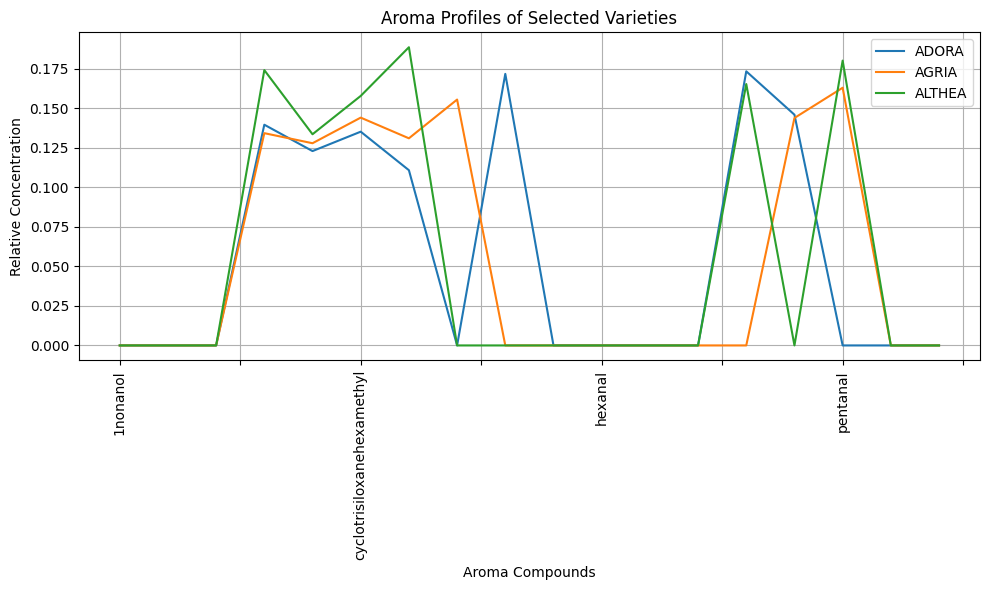

In [34]:
# Plot aroma profiles for selected varieties
selected_varieties = ['ADORA', 'AGRIA', 'ALTHEA']

plt.figure(figsize=(10, 6))
for var in selected_varieties:
    profile = relative_conc.loc[var]
    profile.plot(label=var)

plt.legend()
plt.title('Aroma Profiles of Selected Varieties')
plt.xlabel('Aroma Compounds')
plt.ylabel('Relative Concentration')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


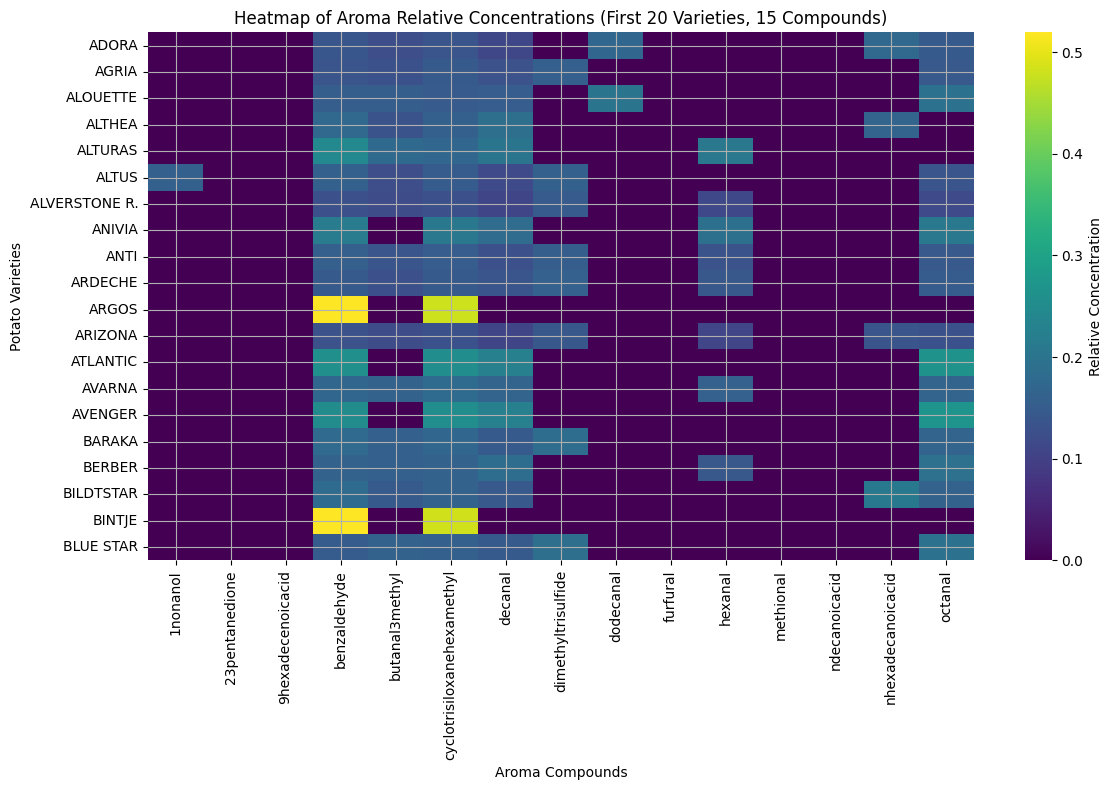

In [35]:


# Heatmap of aroma relative concentrations (subset if too large)
plt.figure(figsize=(12, 8))
sns.heatmap(relative_conc.iloc[:20, :15], cmap='viridis', cbar_kws={'label': 'Relative Concentration'})
plt.title('Heatmap of Aroma Relative Concentrations (First 20 Varieties, 15 Compounds)')
plt.xlabel('Aroma Compounds')
plt.ylabel('Potato Varieties')
plt.tight_layout()
plt.show()

# joining the sensory panel data 

In [19]:
sensory = pd.read_excel(r"C:\Users\fatemehm\Downloads\Sensorial profiling SD 2005.xlsx")
print(sensory.columns)
sensory.head()

Index(['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour',
       'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness',
       'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes',
       'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma',
       'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh',
       'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour',
       'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour',
       'Sweet Flavour', 'Root/ Vegetable Flavour',
       'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel',
       'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh',
       'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin',
       'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste',
       'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47',
       'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK',
       'cluster 3 Sp, clu

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Cleaning of sensory dataset 

In [ ]:
# List of keywords indicating flavor-related columns
FLAVOR_COLS = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste"
]




# --- 1) Ensure/clean VARIETY column ---
if 'VARIETY' not in sensory.columns:
    for cand in ['Variety', 'variety', 'SAMPLE', 'Sample', 'SampleName']:
        if cand in sensory.columns:
            sensory = sensory.rename(columns={cand: 'VARIETY'})
            break
    else:
        raise KeyError("No 'VARIETY' column (or alias) found in `sensory`.")

sensory['VARIETY'] = sensory['VARIETY'].astype(str).str.strip()

# --- 2) Choose flavor columns ---
# Drop any unnamed columns
sensory = sensory.drop(columns=[c for c in sensory.columns if str(c).startswith('Unnamed')], errors='ignore')

# If you already know the flavor columns, intersect here; else fallback to iloc slice 3:47
try:
    FLAVOR_COLS
    flavor_cols = [c for c in FLAVOR_COLS if c in sensory.columns]
    if not flavor_cols:
        flavor_cols = sensory.columns[3:47].tolist()
except NameError:
    # fallback to your original assumption
    flavor_cols = sensory.columns[3:47].tolist()

# --- 3) Coerce numerics & groupby mean per variety ---
sensory_traits = sensory[flavor_cols].apply(pd.to_numeric, errors='coerce')
sensory_traits = sensory_traits.assign(VARIETY=sensory['VARIETY'])

sensory_summary = (
    sensory_traits
    .groupby('VARIETY', as_index=False)
    .mean(numeric_only=True)
)

# --- 4) Quick checks ---
print("Rows (varieties):", sensory_summary['VARIETY'].nunique())
print("Traits averaged:", len(flavor_cols))
print("First rows:")
print(sensory_summary.head())


Rows (varieties): 59
Traits averaged: 44
First rows:
  VARIETY  Thickness of skin  Speckles/Blemishes  Wrinkles  Dryness  \
0   ADORA             23.958              44.438    12.667   40.521   
1   AGATA             18.896              41.417    13.125   33.500   
2   AGRIA             33.875              32.333    10.229   50.979   
3   AMBRA             21.354              28.458    10.333   36.729   
4  AMPERA             24.938              28.875    14.396   45.396   

   Skin Separation  Colour  Visible Ring  Patches/ Blemishes  Waxy/ Shine  \
0           20.188  20.708        13.333               5.521       24.146   
1           25.229  37.167        15.167               3.708       28.771   
2           29.708  64.583        25.792              10.917       16.937   
3           20.479  53.417        23.542               6.104       20.333   
4           19.417  67.271         8.500               2.417       29.354   

   ...  Soft - Flesh  Chewy - Skin  Thickness - Skin  Sta

In [ ]:

# Include 'VARIETY' column for grouping/comparison
flavor_cols = ['VARIETY'] + FLAVOR_COLS

# Extract these columns
sensory_flavors = sensory[flavor_cols].copy()

# Convert all flavor columns to numeric, in case of strings
for col in flavor_cols[1:]:  # skip VARIETY
    sensory_flavors[col] = pd.to_numeric(sensory_flavors[col], errors='coerce')

# Group by VARIETY and average duplicates
sensory_flavors_summary = sensory_flavors.groupby('VARIETY').mean().reset_index()

print(sensory_flavors_summary.head())
len(sensory_flavors_summary['VARIETY'].unique())

  VARIETY  Metallic Flavour  Bitter Flavour  Earthy Flavour  Sour Flavour  \
0   ADORA            17.627          15.329          26.573        10.678   
1   AGATA            10.171          11.633          18.378         7.548   
2   AGRIA             8.018           5.872          20.421         3.787   
3   AMBRA            11.192          12.155          20.334         7.135   
4  AMPERA            13.018          11.176          20.486        11.591   

   Fresh Flavour  Sweet Flavour  Root/ Vegetable Flavour  \
0         24.014          3.098                   17.360   
1         30.340          3.250                   10.600   
2         29.188          1.859                   13.447   
3         33.122          2.729                   17.447   
4         24.644          3.511                   15.991   

   Farmyard (grass/hay) flavour  Bitter Aftertaste  Sour Aftertaste  \
0                        12.520             15.647           14.179   
1                        10.672   

59

In [ ]:


warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (8,5), "axes.grid": True})



# Dominance heuristics (your notebook rules)
P_SHARE, P_Z  = 0.05, 0.50   # present if share ≥5% or z ≥ 0.5
D_SHARE, D_Z  = 0.15, 1.00   # dominant if share ≥15% or z ≥ 1.0

def canon_name(s: str) -> str:
    return re.sub(r"\s*\(.*\)", "", str(s)).strip()

def pick_descriptor(colname: str):
    m = re.search(r"\(([^)]+)\)", str(colname))
    return m.group(1).strip() if m else None

def bh_fdr(p, alpha=0.05):
    p = np.asarray(p, float); n = p.size
    order = np.argsort(p); ranked = p[order]
    thr = (np.arange(1, n+1)/n) * alpha
    ok = ranked <= thr
    if not ok.any(): return np.zeros_like(p, bool)
    k = np.max(np.where(ok)[0]); cut = ranked[k]
    return p <= cut


In [26]:
# Build compound_matrix if needed
if "compound_matrix" not in globals():
    aroma_per_variety = aroma_per_variety.rename(columns=lambda c: c.strip())
    master = master.rename(columns=lambda c: c.strip())
    if "CompoundName" in aroma_per_variety.columns and "Compound Name" not in aroma_sample_df.columns:
        aroma_per_variety = aroma_per_variety.rename(columns={"CompoundName":"Compound Name"})

    # SampleNumber
    if "SampleNumber" not in aroma_per_variety.columns:
        fn = "FileName" if "FileName" in aroma_per_variety.columns else "Filename"
        aroma_per_variety["SampleNumber"] = (
            aroma_per_variety[fn].astype(str).str.extract(r"(\d+)").astype(int)
        )

    # SampleNumber -> Variety
    if {"SampleNumber","Variety"} <= set(master.columns):
        sample_to_variety = master[["SampleNumber","Variety"]].dropna().drop_duplicates()
    else:
        fnm = "Filename" if "Filename" in master.columns else "FileName"
        samp = "Sample" if "Sample" in master.columns else "SampleName"
        qc = {"Blank","QCB","QC1","QC2","QC3","QC4","EnvBlank"}
        m = master[~master[samp].isin(qc)].copy()
        m["SampleNumber"] = m[fnm].astype(str).str.extract(r"_([0-9]+)_B").astype(int)
        m["Variety"] = m[samp].astype(str).str.split(";").str[-1].str.strip()
        sample_to_variety = m[["SampleNumber","Variety"]].dropna().drop_duplicates()

    # Merge + pivot
    long = aroma_sample_df.merge(sample_to_variety, on="SampleNumber", how="left")
    long = long.dropna(subset=["Variety","Compound Name","Intensity"])
    compound_matrix = long.pivot_table(
        index="Variety", columns="Compound Name", values="Intensity", aggfunc="mean"
    )

# Clean + safe column names
compound_matrix = compound_matrix.apply(pd.to_numeric, errors="coerce")
compound_matrix = compound_matrix.loc[:, compound_matrix.notna().any(axis=0)]
pretty = compound_matrix.columns.to_series()
safe   = pretty.str.replace(r"[^0-9A-Za-z]+","_", regex=True).str.strip("_")
name_map_safe2pretty = dict(zip(safe, pretty))
compound_matrix_safe = compound_matrix.copy(); compound_matrix_safe.columns = safe
pd.Series(name_map_safe2pretty).to_json("compound_name_map.json", force_ascii=False)

print(f"compound_matrix: {compound_matrix.shape[0]} varieties × {compound_matrix.shape[1]} compounds")
compound_matrix.head(3)


compound_matrix: 94 varieties × 13 compounds


Compound Name,1-Nonanol,"2,3-Butanedione",Benzaldehyde,"Butanal, 3-methyl-","Cyclotrisiloxane, hexamethyl-",Decanal,Dimethyl trisulfide,Furfural,Hexanal,Hexanoic acid,Methional,Octanal,Pentanal
Variety,,,,,,,,,,,,,
ADORA,NaN,NaN,17.984870,15.836435,17.417208,18.203338,NaN,NaN,NaN,22.334351,NaN,18.799602,NaN
AGRIA,NaN,NaN,14.859493,14.154847,15.947810,14.499810,17.21077,NaN,NaN,NaN,NaN,15.924101,18.039118
ALOUETTE,NaN,NaN,15.205705,15.262178,14.678352,17.462371,NaN,NaN,NaN,NaN,NaN,19.520823,NaN


In [27]:
# Canonicalize (merge duplicate base names)
X_raw = compound_matrix.copy()
Xc = X_raw.copy(); Xc.columns = [canon_name(c) for c in Xc.columns]
Xc = Xc.T.groupby(level=0).sum().T

# Share & z
row_sum = Xc.sum(axis=1).replace(0, np.nan)
share = Xc.div(row_sum, axis=0)
mu, sd = Xc.mean(axis=0), Xc.std(axis=0, ddof=0).replace(0, np.nan)
z = (Xc - mu) / sd

present  = (share.ge(P_SHARE)) | (z.ge(P_Z))
dominant = (share.ge(D_SHARE)) | (z.ge(D_Z))
dom_score = (0.6*share + 0.4*np.tanh(z/2)).fillna(0.0)

# Descriptor shares from original "pretty" columns
comp2desc = {c: pick_descriptor(c) for c in X_raw.columns}
desc_names = sorted({d for d in comp2desc.values() if d and str(d).strip().lower()!="nan"})
share_desc = pd.DataFrame(index=X_raw.index, columns=desc_names, dtype=float)
if desc_names:
    row_sum_raw = X_raw.sum(axis=1).replace(0, np.nan)
    share_raw = X_raw.div(row_sum_raw, axis=0)
    for d in desc_names:
        cols = [c for c in X_raw.columns if comp2desc.get(c)==d]
        share_desc[d] = share_raw[cols].sum(axis=1) if cols else np.nan

# Long forms (as in your notebook)
present_long  = (present.reset_index()
                 .melt(id_vars="Variety", var_name="compound", value_name="present")
                 .query("present==True")[["Variety","compound"]])
dominant_long = (dominant.reset_index()
                 .melt(id_vars="Variety", var_name="compound", value_name="dominant")
                 .query("dominant==True")[["Variety","compound"]])

print("dom_score:", dom_score.shape, "| share_desc:", share_desc.shape)
dominant_long.head(6)


dom_score: (94, 13) | share_desc: (94, 0)


,Variety,compound
5,ALTUS,1-Nonanol
146,INNOVATOR,"2,3-Butanedione"
188,ADORA,Benzaldehyde
190,ALOUETTE,Benzaldehyde
191,ALTHEA,Benzaldehyde
192,ALTURAS,Benzaldehyde


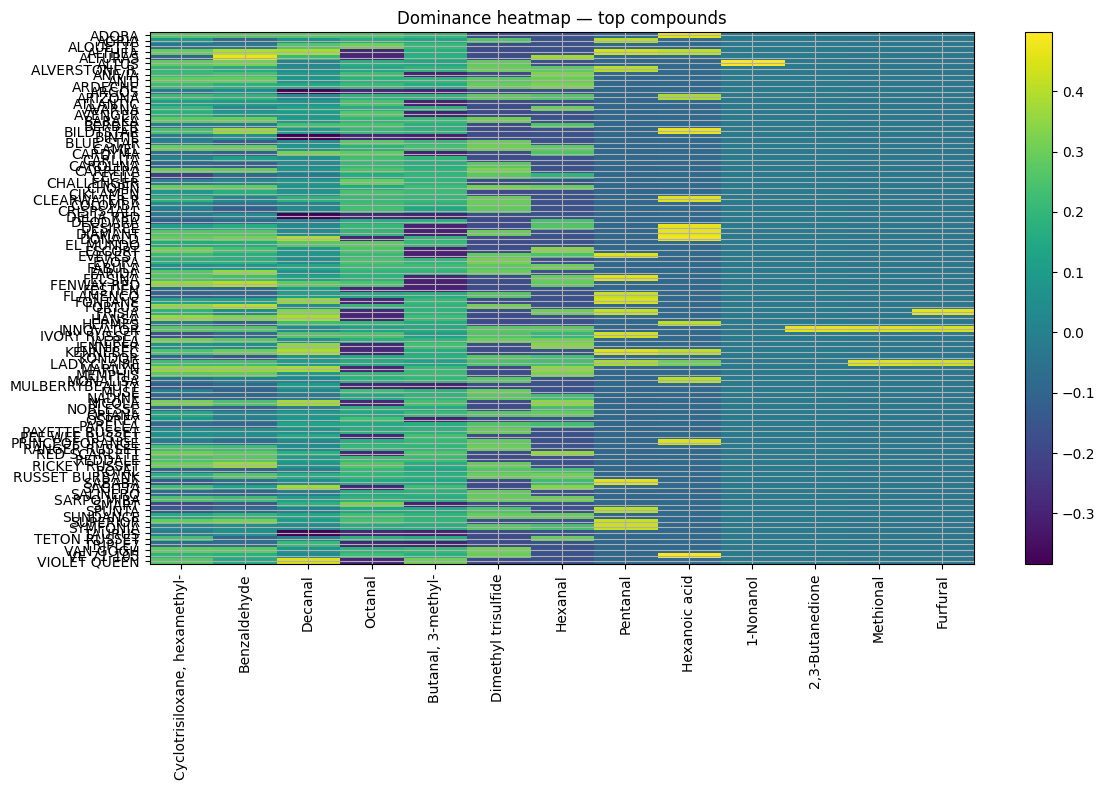

In [28]:
def heatmap(df, title, top_cols=30, cmap="viridis"):
    order = df.mean(axis=0).sort_values(ascending=False)
    cols = list(order.head(min(top_cols, df.shape[1])).index)
    sub = df.loc[:, cols]
    plt.figure(figsize=(12,8))
    plt.imshow(sub.values, aspect="auto", cmap=cmap)
    plt.colorbar()
    plt.xticks(range(sub.shape[1]), cols, rotation=90)
    plt.yticks(range(sub.shape[0]), sub.index)
    plt.title(title)
    plt.tight_layout(); plt.show()

heatmap(dom_score, "Dominance heatmap — top compounds", 30)
if not share_desc.empty:
    heatmap(share_desc.fillna(0), "Descriptor share heatmap — top descriptors", 30)


,Principal component,Eigenvalue,Rate of contribution (%),Cumulative contribution rate (%)
0,1,2.442,18.582,18.582
1,2,2.326,17.702,36.284
2,3,2.022,15.385,51.668
3,4,1.616,12.299,63.968
4,5,1.403,10.675,74.643
5,6,0.917,6.977,81.620


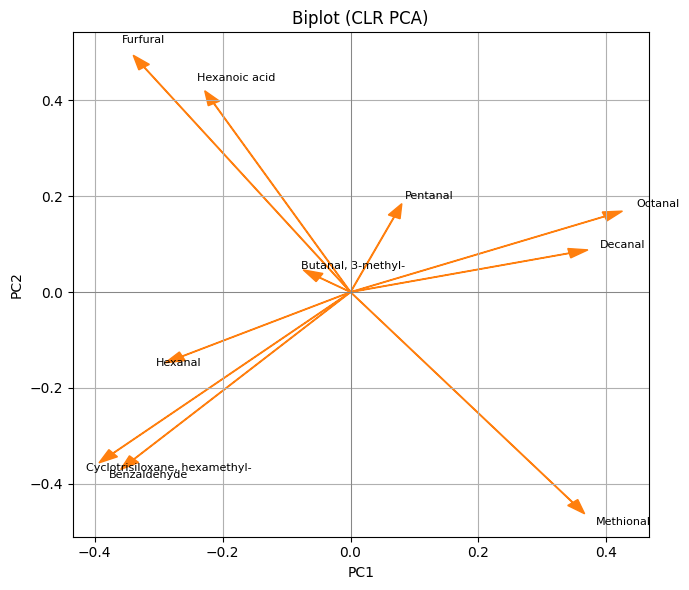

In [29]:
# CLR
def make_clr(cm: pd.DataFrame, eps=1e-9):
    cm = cm.copy().clip(lower=0)
    rs = cm.sum(axis=1).replace(0, np.nan)
    share = cm.div(rs, axis=0)
    logX = np.log(share + eps)
    return logX.sub(logX.mean(axis=1), axis=0)

def pca_from_clr(clr: pd.DataFrame, top_pcs=6):
    X = clr.copy().astype("float64").replace([np.inf,-np.inf], np.nan)
    X = X.loc[:, X.notna().any(axis=0)].fillna(X.mean())
    std0 = X.std(axis=0, ddof=0); X = X.loc[:, std0>0]
    mu, sd = X.mean(), X.std(ddof=0).replace(0, 1e-12)
    Xz = (X - mu) / sd
    n = Xz.shape[0]; C = (Xz.T @ Xz) / (n-1)
    vals, vecs = np.linalg.eigh(C); idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    k = min(top_pcs, len(vals))
    scores = Xz @ vecs[:, :k]
    loadings = pd.DataFrame(vecs[:, :k], index=X.columns, columns=[f"PC{i}" for i in range(1,k+1)])
    scores_df = pd.DataFrame(scores, index=X.index, columns=loadings.columns)
    total = vals.sum(); rates = vals/total*100; cum = np.cumsum(rates)
    table3 = pd.DataFrame({
        "Principal component": np.arange(1,len(vals)+1),
        "Eigenvalue": np.round(vals,3),
        "Rate of contribution (%)": np.round(rates,3),
        "Cumulative contribution rate (%)": np.round(cum,3)
    }).iloc[:k]
    return scores_df, loadings, table3

clr = make_clr(compound_matrix)
scores_df, loadings_df, eigen_table = pca_from_clr(clr, top_pcs=6)
display(eigen_table)

# Biplot PC1–PC2
def biplot(scores, loadings, arrows=10, title="Biplot (PC1–PC2)"):
    plt.figure(figsize=(7,6))
    plt.scatter(scores["PC1"], scores["PC2"], s=22, alpha=0.85)
    plt.axhline(0,color="gray",lw=0.6); plt.axvline(0,color="gray",lw=0.6)
    L = loadings[["PC1","PC2"]].copy()
    L["len"] = np.sqrt(L["PC1"]**2 + L["PC2"]**2)
    for name, r in L.sort_values("len", ascending=False).head(arrows).iterrows():
        plt.arrow(0,0, r["PC1"], r["PC2"], color="C1", head_width=0.02, length_includes_head=True)
        plt.text(r["PC1"]*1.05, r["PC2"]*1.05, name, fontsize=8)
    plt.title(title); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.show()

biplot(scores_df, loadings_df, arrows=10, title="Biplot (CLR PCA)")


In [37]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Loader that works with either a DataFrame in memory or a CSV on disk ----------
def load_pred_flavors_auto(pred: pd.DataFrame | None = None, prefer_cal: bool = True) -> pd.DataFrame:
    """
    Returns Variety×Flavor table. Infers flavor names from columns ending in
    __pred_cal or __pred (prefers calibrated).
    """
    # 0) If a DataFrame was passed (or exists as pred_all), use it
    if pred is None and 'pred_all' in globals():
        pred = globals()['pred_all']
    if pred is None:
        # 1) try to auto-locate a predictions file
        candidates = []
        patterns = [
            "*CALIBRATED*.csv", "*calibrated*.csv",
            "*predictions*.csv", "*prediction*.csv"
        ]
        for pat in patterns:
            candidates.extend(glob.glob(pat))
        if not candidates:
            raise FileNotFoundError(
                "No predictions DataFrame found and no CSV matched patterns "
                f"in {os.getcwd()}. Save your predictions as CSV or keep `pred_all` in memory."
            )
        # choose the most recent file
        path = max(candidates, key=os.path.getmtime)
        pred = pd.read_csv(path)
        print(f"[info] loaded predictions from: {path}")

    # Ensure index is Variety
    if "Variety" in pred.columns:
        pred = pred.set_index("Variety")

    # Infer flavor columns (prefer calibrated)
    picks = {}
    # pass 1: calibrated
    for col in pred.columns:
        m = re.match(r"(.+?)__(pred_cal|pred)$", str(col))
        if m:
            base, kind = m.group(1).strip(), m.group(2)
            if prefer_cal and kind == "pred_cal":
                picks[base] = col
    # pass 2: raw for anything not chosen yet
    for col in pred.columns:
        m = re.match(r"(.+?)__(pred_cal|pred)$", str(col))
        if m:
            base, kind = m.group(1).strip(), m.group(2)
            if base not in picks and kind == "pred":
                picks[base] = col

    if not picks:
        raise ValueError("Couldn’t find any columns ending with __pred_cal or __pred.")

    out = pred[list(picks.values())].copy()
    out.columns = list(picks.keys())
    out = out.apply(pd.to_numeric, errors="coerce")
    # drop flavors that are entirely NaN
    out = out.loc[:, out.notna().any(axis=0)]
    return out

# ---------- Load table (from memory or disk) ----------
flav_tbl = load_pred_flavors_auto()

print(f"Varieties: {flav_tbl.shape[0]} | Flavors: {flav_tbl.shape[1]}")
print("Flavors:", list(flav_tbl.columns))

# ---------- Overall mean bar ----------
avg = flav_tbl.mean(axis=0).sort_values(ascending=False)
plt.figure(figsize=(11,5))
bars = plt.bar(range(len(avg)), avg.values)
plt.xticks(range(len(avg)), avg.index, rotation=45, ha="right")
plt.ylabel("Average score")
plt.title(f"Predicted flavors — overall mean ({flav_tbl.shape[0]} varieties)")
for b, v in zip(bars, avg.values):
    plt.text(b.get_x()+b.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

# ---------- Boxplots per flavor ----------
plt.figure(figsize=(11,5))
plt.boxplot([flav_tbl[c].dropna().values for c in avg.index],
            labels=avg.index, showmeans=True)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Predicted flavors — distribution across varieties")
plt.tight_layout()
plt.show()

# ---------- Descriptive stats (same order as plots) ----------
desc = pd.DataFrame({
    "mean":   flav_tbl.mean(),
    "median": flav_tbl.median(),
    "std":    flav_tbl.std(ddof=0),
    "n":      flav_tbl.notna().sum()
}).loc[avg.index].round(3)

display(desc)


FileNotFoundError: No predictions DataFrame found and no CSV matched patterns in c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship. Save your predictions as CSV or keep `pred_all` in memory.

In [ ]:
def load_pred_flavors(path="rankfirst_predictions_all_varieties_CALIBRATED.csv"):
    if not os.path.exists(path): return pd.DataFrame()
    df = pd.read_csv(path)
    if "Variety" in df.columns: df = df.set_index("Variety")
    cols = []
    for f in FLAVOR_COLS:
        if f"{f}__pred_cal" in df.columns: cols.append(f"{f}__pred_cal")
        elif f"{f}__pred" in df.columns:   cols.append(f"{f}__pred")
    if not cols: return pd.DataFrame()
    out = df[cols].rename(columns=lambda c: c.replace("__pred_cal","").replace("__pred",""))
    return out.apply(pd.to_numeric, errors="coerce")

flav_tbl = load_pred_flavors().reindex(compound_matrix.index)

# Overall mean bar + boxplots
avg = flav_tbl.mean(axis=0).sort_values(ascending=False)
plt.figure(figsize=(10,5))
bars = plt.bar(range(len(avg)), avg.values)
plt.xticks(range(len(avg)), avg.index, rotation=45, ha="right")
plt.ylabel("Average score"); plt.title("Predicted flavors — overall mean (94 varieties)")
for b,v in zip(bars, avg.values):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
plt.boxplot([flav_tbl[c].values for c in avg.index], labels=avg.index, showmeans=True)
plt.xticks(rotation=45, ha="right"); plt.ylabel("Score")
plt.title("Predicted flavors — distribution across 94 varieties")
plt.tight_layout(); plt.show()

desc = pd.DataFrame({"mean":flav_tbl.mean(),"median":flav_tbl.median(),"std":flav_tbl.std(ddof=0),"n":flav_tbl.notna().sum()}).loc[avg.index]
display(desc)


In [ ]:
# Spearman (dominance vs flavors)
rows = []
for comp in dom_score.columns:
    for flv in flav_tbl.columns:
        r, p = spearmanr(dom_score[comp], flav_tbl[flv])
        rows.append((comp, flv, r, p))
corr_comp = pd.DataFrame(rows, columns=["compound","flavor","rho","p"])
corr_comp["sig"] = False
for flv, sub in corr_comp.groupby("flavor"):
    mask = ~sub["p"].isna()
    corr_comp.loc[sub.index[mask], "sig"] = bh_fdr(sub.loc[mask,"p"], 0.05)
display(corr_comp[corr_comp["sig"]].sort_values("rho", ascending=False).head(15))
corr_comp.to_csv("Compound_Flavor_Spearman_FDR.csv", index=False)

# PLS + VIP (aroma features → each flavor)
Xfeat = dom_score.fillna(0).loc[:, dom_score.std(ddof=0)>0]
Xz = StandardScaler().fit_transform(Xfeat.values)
def pls_vip(pls, X, y):
    T = pls.x_scores_; W = pls.x_weights_; Q = pls.y_loadings_
    p,h = W.shape; ssy = np.sum((T @ Q.T)**2, axis=0); tot = np.sum(ssy)
    vip = np.sqrt(p * ((W**2) * ssy).sum(axis=1) / (tot + 1e-12))
    return vip

perf, vips = [], []
for flv in flav_tbl.columns:
    y = flav_tbl[flv].values
    best_r2, best_k = -1e9, None
    for k in range(1, min(10, Xz.shape[1])+1):
        pls = PLSRegression(n_components=k)
        r2 = np.mean([pls.fit(np.delete(Xz,i,0), np.delete(y,i,0)).score(Xz[i:i+1], y[i:i+1])
                      for i in range(len(y))])  # LOOCV-ish quick check
        if r2 > best_r2: best_r2, best_k = r2, k
    pls = PLSRegression(n_components=best_k).fit(Xz, y)
    vip = pls_vip(pls, Xz, y)
    perf.append({"flavor":flv,"best_k":best_k,"approx_cvR2":float(best_r2)})
    for j,name in enumerate(Xfeat.columns):
        vips.append({"flavor":flv,"feature":name,"VIP":float(vip[j])})

pls_perf = pd.DataFrame(perf).sort_values("approx_cvR2", ascending=False)
pls_vips  = pd.DataFrame(vips)
display(pls_perf.head(10))
pls_perf.to_csv("PLS_Performance_By_Flavor.csv", index=False)
pls_vips.to_csv("PLS_VIP_By_Flavor.csv", index=False)


In [ ]:
# Composite Flavor Index from first 3 CLR-PCA scores (0–100)
S = scores_df.copy()
S = (S - S.mean()) / (S.std(ddof=0) + 1e-12)
w = np.array([0.5, 0.3, 0.2] + [0]*(S.shape[1]-3))[:S.shape[1]]
cfi_raw = (S.values * w).sum(axis=1)
cfi = (cfi_raw - cfi_raw.min())/(cfi_raw.max()-cfi_raw.min()+1e-12)*100
indices = pd.DataFrame({"CompositeFlavorIndex": cfi}, index=S.index)

# Aroma complexity (Shannon entropy over compound shares)
def shannon(row):
    p = row.values; p = p[p>0]
    return -np.sum(p*np.log(p)) if p.size else 0.0
indices["AromaComplexity"] = share.apply(shannon, axis=1)

display(indices.sort_values("CompositeFlavorIndex", ascending=False).head(10))
indices.to_csv("Variety_Indices.csv")

# KMeans clustering on flavors (auto k by silhouette)
Z = StandardScaler().fit_transform(flav_tbl.fillna(flav_tbl.median()).values)
best, best_k = -1, None
for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42).fit(Z)
    sil = silhouette_score(Z, km.labels_)
    if sil > best: best, best_k, labels = sil, k, km.labels_
clusters = pd.Series(labels, index=flav_tbl.index, name=f"Cluster_k{best_k}")
clusters.to_csv("Flavor_Clusters.csv")
cluster_means = flav_tbl.groupby(clusters).mean()
display(cluster_means)


In [ ]:
# Top compounds/descriptors/flavors per variety
def collapse_unique(series, max_items=10):
    vals = [str(x) for x in series if pd.notna(x) and str(x).strip()]
    return "; ".join(list(dict.fromkeys(vals))[:max_items])

rows = []
for v in compound_matrix.index:
    comp_dom = dominant_long.loc[dominant_long["Variety"]==v, "compound"]
    desc_dom = [] if share_desc.empty else \
               share_desc.loc[[v]].T.sort_values(by=v, ascending=False).head(10).index
    flav_top = flav_tbl.loc[[v]].T.sort_values(by=v, ascending=False).head(3).index if v in flav_tbl.index else []
    rows.append({
        "Variety": v,
        "Dominant_compounds":   collapse_unique(comp_dom),
        "Dominant_descriptors": collapse_unique(desc_dom),
        "Top_flavors":          collapse_unique(flav_top, 3)
    })
summary_table = pd.DataFrame(rows).set_index("Variety").sort_index()
display(summary_table.head(8))

# Excel
try:
    import xlsxwriter  # ensure engine present
    with pd.ExcelWriter("Variety_Dominance_Report.xlsx", engine="xlsxwriter") as xw:
        compound_matrix.to_excel(xw, sheet_name="Raw_Compound_Intensity")
        share.to_excel(xw, sheet_name="Compound_Share")
        z.to_excel(xw, sheet_name="Compound_Zscore")
        dom_score.to_excel(xw, sheet_name="Dominance_Score")
        if not share_desc.empty: share_desc.to_excel(xw, sheet_name="Descriptor_Share")
        scores_df.to_excel(xw, sheet_name="CLR_PCA_Scores")
        loadings_df.to_excel(xw, sheet_name="CLR_PCA_Loadings")
        eigen_table.to_excel(xw, sheet_name="CLR_PCA_Table3", index=False)
        flav_tbl.to_excel(xw, sheet_name="Predicted_Flavors")
        summary_table.to_excel(xw, sheet_name="Per_Variety_Summary")
    print("Wrote Variety_Dominance_Report.xlsx")
except Exception as e:
    print("Excel export skipped:", e)


In [ ]:
try:
    import ipywidgets as w
    from IPython.display import display, clear_output

    varieties = list(compound_matrix.index)
    dd = w.Dropdown(options=varieties, description="Variety", value=varieties[0])
    out = w.Output()

    def render(v):
        with out:
            clear_output(wait=True)
            fig, axs = plt.subplots(1,2, figsize=(12,4))
            # flavors
            if v in flav_tbl.index:
                s = flav_tbl.loc[v].sort_values(ascending=False)
                axs[0].bar(s.index, s.values); axs[0].set_title(f"Flavors — {v}")
                axs[0].tick_params(axis='x', rotation=60)
            else:
                axs[0].axis("off"); axs[0].set_title("Flavors (n/a)")
            # compounds
            c = dom_score.loc[v].sort_values(ascending=False).head(10)
            axs[1].bar(c.index, c.values); axs[1].set_title("Top compounds (dominance)")
            axs[1].tick_params(axis='x', rotation=60)
            plt.tight_layout(); plt.show()

    def on_change(ch):
        if ch["name"]=="value": render(ch["new"])

    dd.observe(on_change); display(dd, out); render(dd.value)
except Exception as e:
    print("ipywidgets skipped:", e)
